In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
import warnings
warnings.filterwarnings("ignore", category=UserWarning, module="pandas")

# Step 1: Load the dataset
df = pd.read_csv("austo_automobile.csv")
print("Shape:", df.shape)
#df.info()
#df.dtypes
df.head()

Shape: (1581, 14)


,Age,Gender,Profession,Marital_status,Education,No_of_Dependents,Personal_loan,House_loan,Partner_working,Salary,Partner_salary,Total_salary,Price,Make
0,53,Male,Business,Married,Post Graduate,4,No,No,Yes,99300,70700.0,170000,61000,SUV
1,53,Femal,Salaried,Married,Post Graduate,4,Yes,No,Yes,95500,70300.0,165800,61000,SUV
2,53,Female,Salaried,Married,Post Graduate,3,No,No,Yes,97300,60700.0,158000,57000,SUV
3,53,Female,Salaried,Married,Graduate,2,Yes,No,Yes,72500,70300.0,142800,61000,SUV
4,53,Male,Salaried,Married,Post Graduate,3,No,No,Yes,79700,60200.0,139900,57000,SUV


Shape: (1581, 14)
   Age  Gender Profession Marital_status      Education  No_of_Dependents  \
0   53    Male   Business        Married  Post Graduate                 4   
1   53   Femal   Salaried        Married  Post Graduate                 4   
2   53  Female   Salaried        Married  Post Graduate                 3   
3   53  Female   Salaried        Married       Graduate                 2   
4   53    Male   Salaried        Married  Post Graduate                 3   

  Personal_loan House_loan Partner_working  Salary  Partner_salary  \
0            No         No             Yes   99300         70700.0   
1           Yes         No             Yes   95500         70300.0   
2            No         No             Yes   97300         60700.0   
3           Yes         No             Yes   72500         70300.0   
4            No         No             Yes   79700         60200.0   

   Total_salary  Price Make  
0        170000  61000  SUV  
1        165800  61000  SUV  
2       

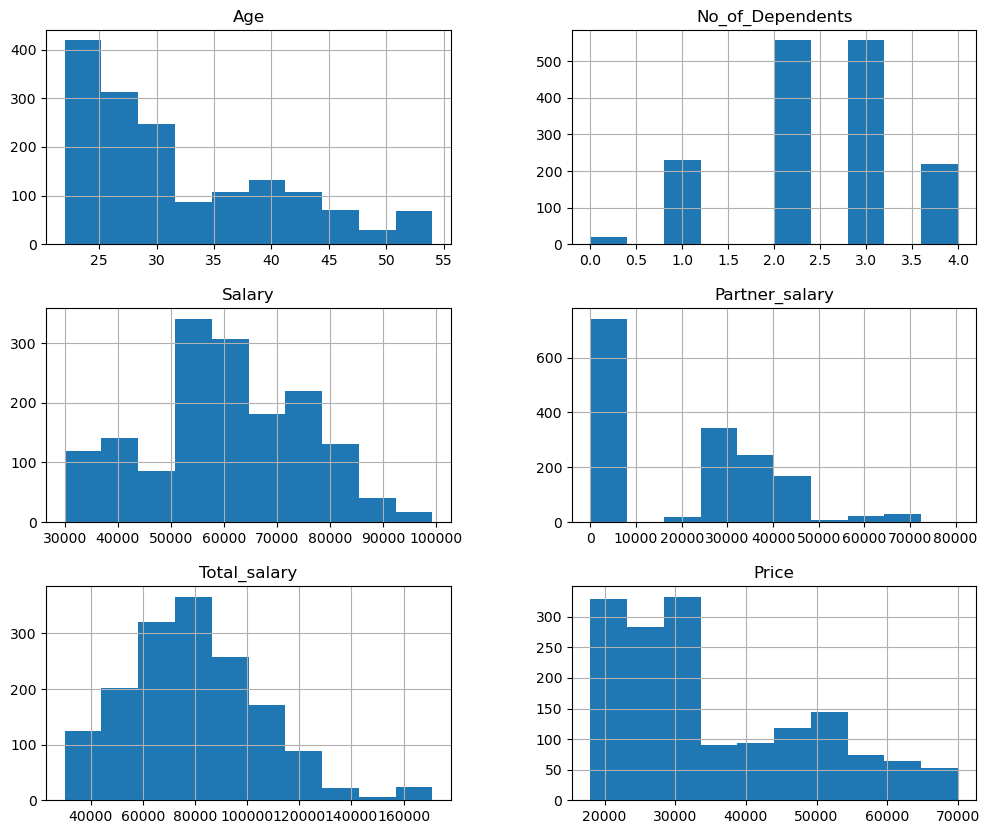


 Age
Mean: 31.922201138519924
Median: 29.0
Std: 8.425978166558165
Skewness: 0.8930870865867485


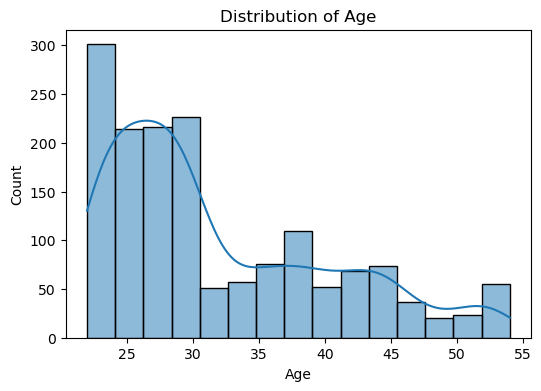

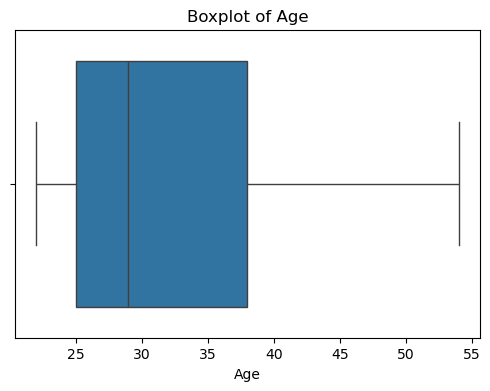


 No_of_Dependents
Mean: 2.4579380139152436
Median: 2.0
Std: 0.9434829353622931
Skewness: -0.1298080480109239


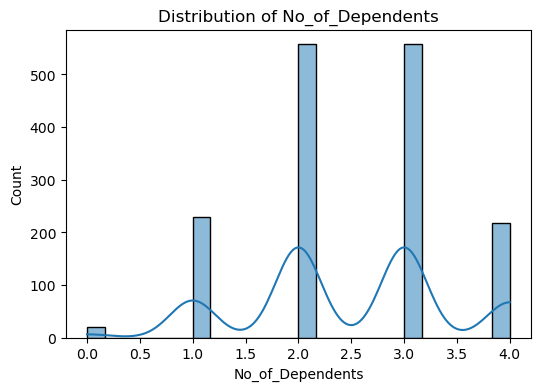

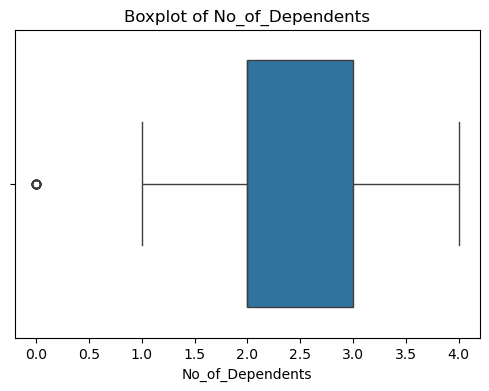


 Salary
Mean: 60392.220113851996
Median: 59500.0
Std: 14674.825043862535
Skewness: -0.011570808595835032


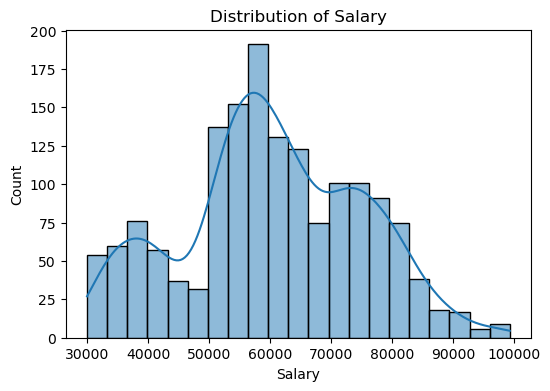

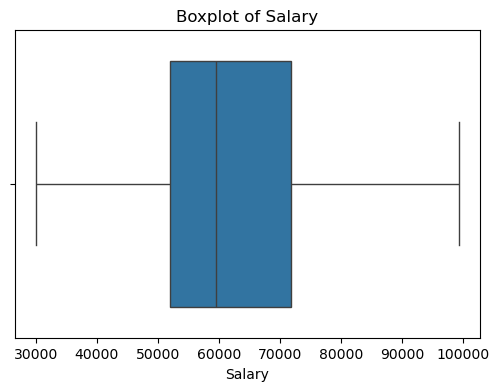


 Partner_salary
Mean: 19202.466793168882
Median: 25100.0
Std: 19526.571321713494
Skewness: 0.41471622285810483


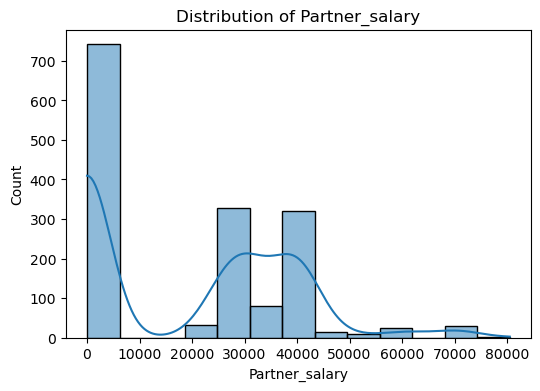

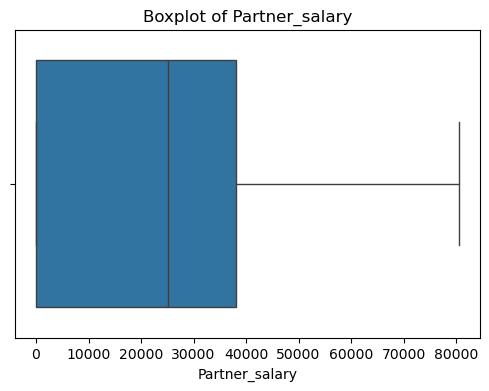


 Total_salary
Mean: 79625.99620493359
Median: 78000.0
Std: 25545.8577676707
Skewness: 0.6097056414760922


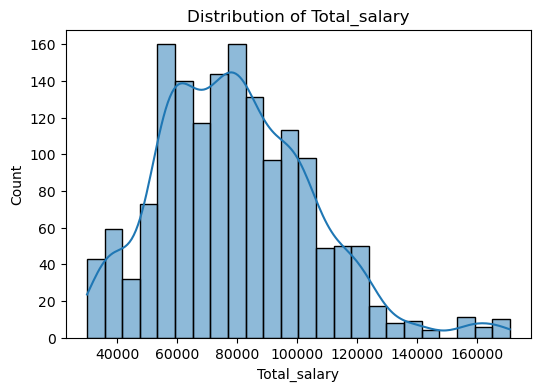

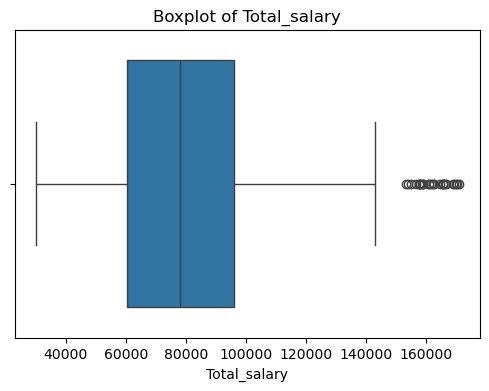


 Price
Mean: 35597.722960151805
Median: 31000.0
Std: 13633.636545130645
Skewness: 0.7408739566673956


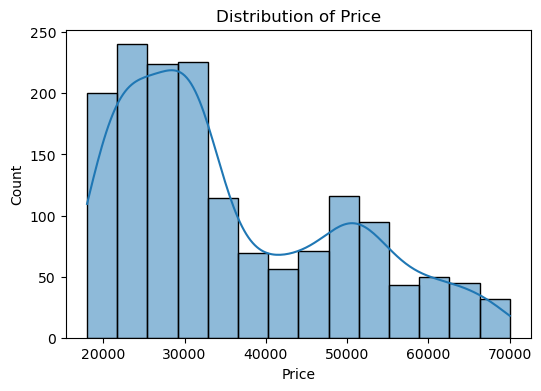

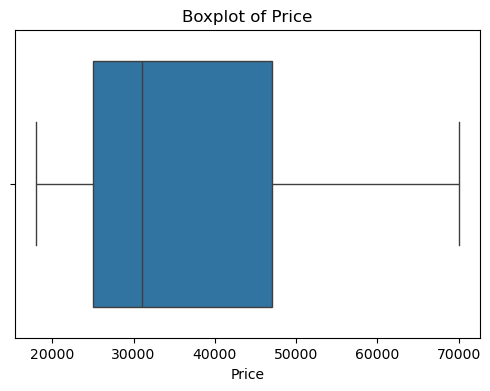


 Gender
Gender
Male      1252
Female     329
Name: count, dtype: int64


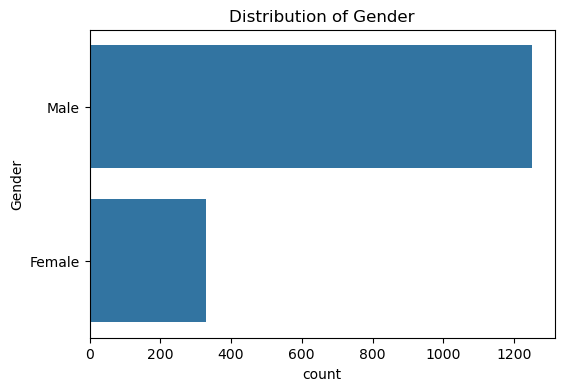


 Profession
Profession
Salaried    896
Business    685
Name: count, dtype: int64


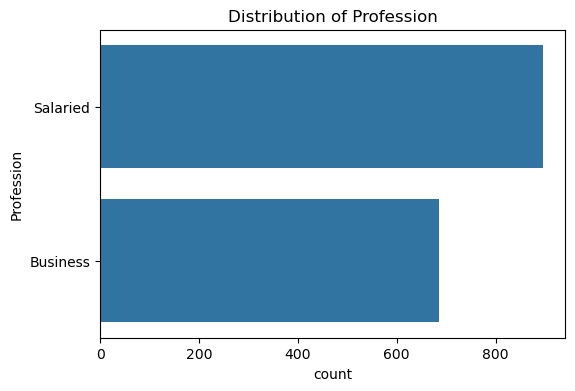


 Marital_status
Marital_status
Married    1443
Single      138
Name: count, dtype: int64


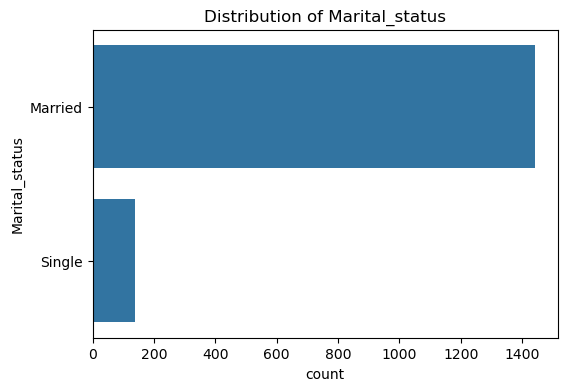


 Education
Education
Post Graduate    985
Graduate         596
Name: count, dtype: int64


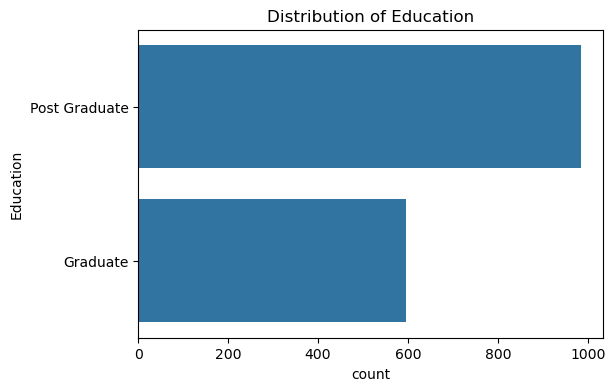


 Personal_loan
Personal_loan
Yes    792
No     789
Name: count, dtype: int64


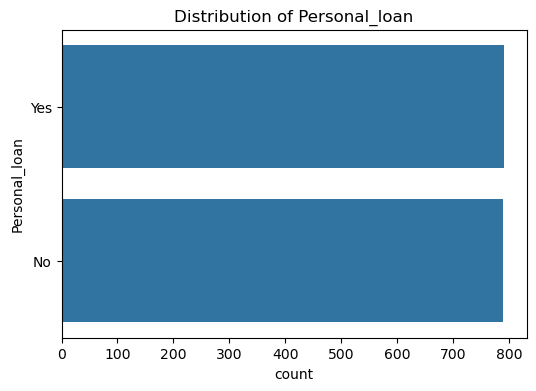


 House_loan
House_loan
No     1054
Yes     527
Name: count, dtype: int64


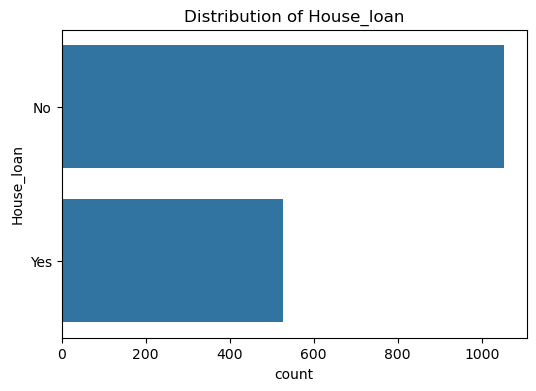


 Partner_working
Partner_working
Yes    868
No     713
Name: count, dtype: int64


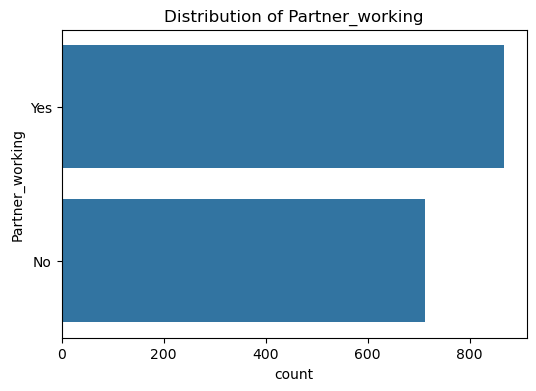


 Make
Make
Sedan        702
Hatchback    582
SUV          297
Name: count, dtype: int64


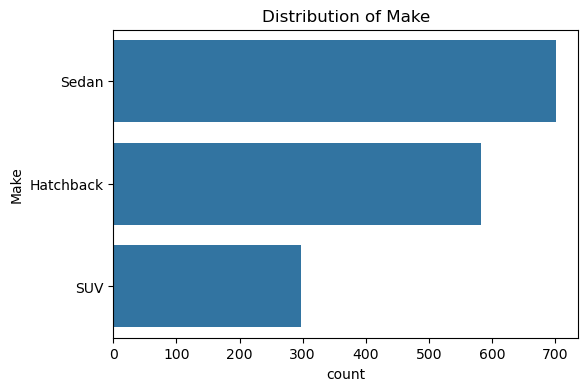

In [16]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
import warnings

warnings.filterwarnings("ignore", category=UserWarning, module="pandas")

# Step 1: Load dataset
df = pd.read_csv("austo_automobile.csv")

print("Shape:", df.shape)

# Basic inspection
print(df.head())
print(df.dtypes)
print(df.info())

print(df.describe().round(2))
df.columns = df.columns.str.strip()

# Missing values
print(df.isnull().sum())

# Gender cleaning
print(df['Gender'].value_counts())

df['Gender'] = df['Gender'].replace({
    'Femal': 'Female',
    'Femle': 'Female'
})

print(df['Gender'].value_counts())

# Missing + zero values analysis
missing = df.isna().sum() + (df == 0).sum()

M_P = (missing / len(df)) * 100
print(M_P.round(2).astype(str) + '%')

# Partner salary analysis
#print(df['Partner_salary'].describe().round(2))
#print(df['Partner_salary'].value_counts())
df['Partner_salary'] = df.groupby('Partner_working')['Partner_salary'].transform(
    lambda x: x.fillna(x.median())
)

print(df['Partner_salary'].isnull().sum())
print(df.isnull().sum())
df['Gender'] = df['Gender'].fillna(df['Gender'].mode()[0])
print(df.isnull().sum())

#check numerical & Categorical col
num_cols = df.select_dtypes(include=np.number).columns
cat_cols = df.select_dtypes(exclude=np.number).columns
 
print("Numerical Columns:")
print(num_cols)

print("\nCategorical Columns:")
print(cat_cols)

df[num_cols].hist(figsize=(12,10))
plt.show()
for col in num_cols:
    print("\n", col)
    print("Mean:", df[col].mean())
    print("Median:", df[col].median())
    print("Std:", df[col].std())
    print("Skewness:", df[col].skew())

    plt.figure(figsize=(6,4))
    sns.histplot(df[col], kde=True)
    plt.title(f"Distribution of {col}")
    plt.show()

    plt.figure(figsize=(6,4))
    sns.boxplot(x=df[col])
    plt.title(f"Boxplot of {col}")
    plt.show()

for col in cat_cols:
    print("\n", col)
    print(df[col].value_counts())

    plt.figure(figsize=(6,4))
    sns.countplot(y=df[col], order=df[col].value_counts().index)
    plt.title(f"Distribution of {col}")
    plt.show()


In [ ]:
df.dtypes

In [ ]:
df.columns = df.columns.str.strip()
print(df.columns)

In [ ]:
print(df.info())
#print("Shape:", df.shape)

In [ ]:
df.describe().round(2)

In [ ]:
print(df.isnull().sum())
#df.isna().sum()

In [ ]:
print(df['Gender'].unique())
print(df['Gender'].value_counts())

In [7]:
df['Gender'] = df['Gender'].replace({
    'Femal': 'Female',
    'Femle': 'Female'
})
print(df['Gender'].value_counts())

Gender
Male      1252
Female     329
Name: count, dtype: int64


In [ ]:
missing = df.isna().sum() + (df == 0).sum()
M_P=((df.isna().sum() + (df == 0).sum()) / len(df)) * 100
print(M_P.round(2).astype(str) + '%')

In [ ]:
df['Partner_salary'].describe().round(2)


In [ ]:
#print(df['Partner_salary'].unique())
print(df['Partner_salary'].value_counts())

In [ ]:
num_cols = df.select_dtypes(include=np.number).columns
cat_cols = df.select_dtypes(exclude=np.number).columns

print("Numerical Columns:")
print(num_cols)

print("\nCategorical Columns:")
print(cat_cols)

In [ ]:
pd.crosstab(df['Partner_working'], df['Partner_salary'].isnull())

In [ ]:
df['Partner_salary'] = df.groupby('Partner_working')['Partner_salary'].transform(
    lambda x: x.fillna(x.median())
)

print(df['Partner_salary'].isnull().sum())

In [5]:
df['Gender'].fillna(df['Gender'].mode()[0], inplace=True)


C:\Users\Siddhartha\AppData\Local\Temp\ipykernel_14024\700870124.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['Gender'].fillna(df['Gender'].mode()[0], inplace=True)


In [ ]:
df['Gender'].fillna(df['Gender'].mode()[0], inplace=True)
print(df.isnull().sum())

In [ ]:
print(df.duplicated().sum())
(df['Partner_salary'] == 0).sum()
pd.crosstab(df['Partner_working'], df['Partner_salary'] == 0)

In [6]:
#df[num_cols].hist(figsize=(12,10))
#plt.show()

In [ ]:
df[num_cols].describe().round(2)


In [ ]:
for col in num_cols:
    print("\n", col)
    print("Mean:", df[col].mean())
    print("Median:", df[col].median())
    print("Std:", df[col].std())
    print("Skewness:", df[col].skew())

    plt.figure(figsize=(6,4))
    sns.histplot(df[col], kde=True)
    plt.title(f"Distribution of {col}")
    plt.show()

    plt.figure(figsize=(6,4))
    sns.boxplot(x=df[col])
    plt.title(f"Boxplot of {col}")
    plt.show()
    

In [ ]:
for col in cat_cols:
    print("\n", col)
    print(df[col].value_counts())

    plt.figure(figsize=(6,4))
    sns.countplot(y=df[col], order=df[col].value_counts().index)
    plt.title(f"Distribution of {col}")
    plt.show()

In [ ]:
for col in num_cols:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1

    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR

    outliers = df[(df[col] < lower) | (df[col] > upper)]
    
    print(f"{col}: {len(outliers)} outliers")

In [9]:
df['Gender'].unique()
df['Gender'].value_counts(normalize=True) * 100

Gender
Male      79.190386
Female    20.809614
Name: proportion, dtype: float64

In [8]:
pd.crosstab([df['Gender'], df['Marital_status']], df['Make'])

Make                   Hatchback  SUV  Sedan
Gender Marital_status                       
Female Married                14  166    127
       Single                  1    7     14
Male   Married               484  115    537
       Single                 83    9     24

In [20]:
pd.crosstab(df['Profession'], df['Make'])

Make,Hatchback,SUV,Sedan
Profession,,,
Business,290,89,306
Salaried,292,208,396


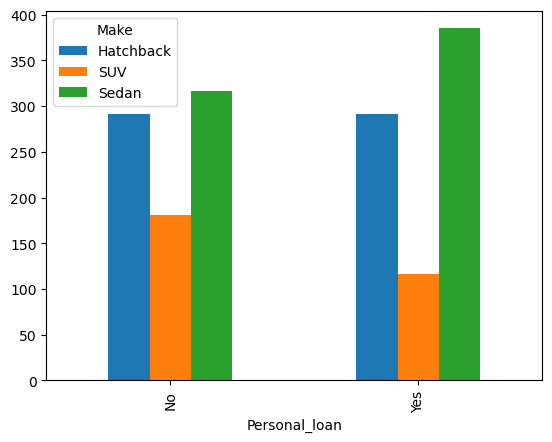

In [12]:
pd.crosstab(df['Personal_loan'], df['Make']).plot(kind='bar')
plt.show()

In [15]:
df[['Salary','Price']].corr().round(2)

,Salary,Price
Salary,1.0,0.4
Price,0.4,1.0


In [18]:
df[['Age','No_of_Dependents','Salary','Partner_salary','Total_salary']].corr().round(2)


,Age,No_of_Dependents,Salary,Partner_salary,Total_salary
Age,1.00,-0.19,0.62,0.13,0.46
No_of_Dependents,-0.19,1.00,-0.03,0.14,0.09
Salary,0.62,-0.03,1.00,0.08,0.64
Partner_salary,0.13,0.14,0.08,1.00,0.81
Total_salary,0.46,0.09,0.64,0.81,1.00
